# Phase 2 : EDA diagnostique

Projet final Machine Learning, blocs 6 et 8.

## Objectif de ce notebook

Évaluer la qualité des données avant de les analyser, sur les cinq dimensions du guide :
complétude, unicité, cohérence, exactitude, fraîcheur. Produire un rapport priorisé qui
dise quoi corriger, dans quel ordre, et pourquoi.

Ce notebook **ne corrige rien**. Il mesure et il documente. Toute correction appartient
à la phase 3.

## Une interdiction à respecter

Le guide est explicite : l'imputation des valeurs manquantes est **interdite à ce stade**.
Remplacer un trou par une moyenne calculée sur l'ensemble des données injecterait dans le
jeu d'entraînement une information tirée du jeu de test, ce qui est exactement la fuite de
données qui plafonne la phase de modélisation à 8 sur 25.

On compte donc les valeurs manquantes, on les qualifie, et on s'arrête là. L'imputation
viendra en phase 7, à l'intérieur d'un `Pipeline` ajusté sur le seul jeu d'entraînement.

## Livrable

`docs/rapport_diagnostic.md`, généré par la section 8 à partir des valeurs calculées ici,
pour qu'aucun chiffre du rapport ne puisse diverger du code.

## 0. Configuration et chargement

Le chargement typé est désormais dans `src/extraction.py::load_split_frames`. La phase 1 le
détaillait cellule par cellule parce que c'était l'objet de sa notation. Ici on l'appelle,
ce qui garantit que les deux notebooks appliquent la même politique de types et de dates.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src import config, extraction, quality

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)

oe, oe_joueurs = extraction.load_split_frames()
ligues = extraction.load_league_reference()

print()
print(f"Période : {oe['date'].min():%Y-%m-%d} à {oe['date'].max():%Y-%m-%d}")

  saison 2022 : 150,348 lignes, 165 colonnes


  saison 2023 : 133,272 lignes, 165 colonnes


  saison 2024 : 122,340 lignes, 165 colonnes


  saison 2025 : 120,492 lignes, 165 colonnes


  saison 2026 : 100,812 lignes, 165 colonnes
Lignes équipe :  104,544 | lignes joueur :  522,720



Période : 2022-01-10 à 2026-09-06


In [2]:
# Palette charcoal et slate, commune à toutes les figures du projet.
PALETTE = config.PALETTE
CMAP_ARDOISE = LinearSegmentedColormap.from_list(
    "ardoise", [PALETTE["highlight"], "#E8D5C4", PALETTE["accent"], PALETTE["primary"]]
)

plt.rcParams.update({
    "figure.facecolor": PALETTE["background"],
    "axes.facecolor": PALETTE["background"],
    "axes.edgecolor": PALETTE["secondary"],
    "axes.labelcolor": PALETTE["primary"],
    "text.color": PALETTE["primary"],
    "xtick.color": PALETTE["secondary"],
    "ytick.color": PALETTE["secondary"],
    "grid.color": PALETTE["grid"],
    "font.size": 10,
})

config.FIGURES.mkdir(parents=True, exist_ok=True)
print("Figures écrites dans :", config.FIGURES)

Figures écrites dans : E:\LWP(LoLWinPrediciton)\lol-win-prediction\figures


## 1. Complétude

Question : des données manquent-elles, et est-ce aléatoire ou systématique ?

La distinction est le coeur du diagnostic. Un trou aléatoire se traite ligne par ligne. Un
trou systématique, concentré sur une ligue ou une saison, raconte quelque chose sur la
collecte et se traite en bloc.

In [3]:
manquants = pd.DataFrame({
    "n_manquant": oe.isna().sum(),
    "pct_manquant": (100 * oe.isna().mean()).round(1),
}).sort_values("pct_manquant", ascending=False)

# Seuils de criticité repris du guide de phase 2.
def criticite(pct):
    if pct > 30:
        return "haute"
    if pct >= 5:
        return "moyenne"
    if pct > 0:
        return "faible"
    return "aucune"

manquants["criticite"] = manquants["pct_manquant"].map(criticite)

print(f"{oe.shape[1]} colonnes sur les lignes équipe")
print(manquants["criticite"].value_counts().reindex(
    ["haute", "moyenne", "faible", "aucune"]).to_string())
print()
print("Vingt colonnes les plus incomplètes :")
print(manquants.head(20).to_string())

165 colonnes sur les lignes équipe
criticite
haute      17
moyenne    96
faible      6
aucune     46

Vingt colonnes les plus incomplètes :
                         n_manquant  pct_manquant criticite
firstbloodassist             104544         100.0     haute
earnedgoldshare              104544         100.0     haute
champion                     104544         100.0     haute
firstbloodkill               104544         100.0     haute
playerid                     104544         100.0     haute
playername                   104544         100.0     haute
firstbloodvictim             104544         100.0     haute
total cs                     104544         100.0     haute
damageshare                  104544         100.0     haute
monsterkillsownjungle         92548          88.5     haute
monsterkillsenemyjungle       92548          88.5     haute
dragons (type unknown)        92002          88.0     haute
url                           91476          87.5     haute
atakhans            

### 1.1 Neuf colonnes vides à 100 %, et c'est normal

Ces colonnes ne sont pas des trous : ce sont des champs de **ligne joueur**, lus sur des
lignes équipe. Un agrégat d'équipe n'a ni `playername`, ni `champion`, ni `damageshare`.

Oracle's Elixir mélange deux granularités dans un seul tableau, et les colonnes de l'une
sont vides sur les lignes de l'autre. Les compter comme des données manquantes serait une
erreur de lecture, pas un problème de qualité.

In [4]:
vides = manquants[manquants["pct_manquant"] == 100].index.tolist()
print(f"{len(vides)} colonnes vides à 100 % sur les lignes équipe :")
print(vides)
print()
print("Contre-preuve, ces colonnes sur les lignes joueur (% renseigné) :")
temoins = [c for c in ["champion", "playername", "playerid"] if c in oe_joueurs.columns]
print((100 * oe_joueurs[temoins].notna().mean()).round(1).to_string())

9 colonnes vides à 100 % sur les lignes équipe :
['firstbloodassist', 'earnedgoldshare', 'champion', 'firstbloodkill', 'playerid', 'playername', 'firstbloodvictim', 'total cs', 'damageshare']

Contre-preuve, ces colonnes sur les lignes joueur (% renseigné) :
champion      100.0
playername    100.0


### 1.2 Le snapshot à 15 minutes, la seule complétude qui décide

Les colonnes `at15` portent l'instant de prédiction du projet. Une ligne sans elles est
inutilisable, quelle que soit la qualité du reste.

In [5]:
at15_ok = oe[config.REQUIRED_AT15].notna().all(axis=1)

print("Colonnes requises :", config.REQUIRED_AT15)
print()
print(f"Lignes équipe complètes  : {int(at15_ok.sum()):,} sur {len(oe):,} "
      f"({100 * at15_ok.mean():.1f} %)")
print(f"Lignes équipe à écarter  : {int((~at15_ok).sum()):,} "
      f"({100 * (~at15_ok).mean():.1f} %)")
print()

# La règle d'inclusion travaille par partie : si une seule des deux lignes est
# incomplète, la partie entière part, sinon l'équilibre 50/50 se casse.
oe["_at15_ok"] = at15_ok
parties_completes = oe.groupby("gameid")["_at15_ok"].all()

perte_ligne = int((~at15_ok).sum())
perte_partie = int((~parties_completes).sum()) * 2

print(f"Parties entièrement exploitables : {int(parties_completes.sum()):,} "
      f"sur {len(parties_completes):,} ({100 * parties_completes.mean():.1f} %)")
print()
print("Effet de la règle des deux lignes :")
print(f"  lignes incomplètes                     : {perte_ligne:,}")
print(f"  lignes réellement perdues, par paires  : {perte_partie:,}")
print(f"  surcoût de la règle                    : {perte_partie - perte_ligne:,} lignes")

Colonnes requises : ['goldat15', 'xpat15', 'csat15', 'golddiffat15', 'xpdiffat15']

Lignes équipe complètes  : 92,616 sur 104,544 (88.6 %)
Lignes équipe à écarter  : 11,928 (11.4 %)

Parties entièrement exploitables : 46,308 sur 52,272 (88.6 %)

Effet de la règle des deux lignes :
  lignes incomplètes                     : 11,928
  lignes réellement perdues, par paires  : 11,928
  surcoût de la règle                    : 0 lignes


Le surcoût est le prix de l'équilibre de la cible. Quelques centaines de lignes valides sont
sacrifiées parce que leur adversaire n'a pas de snapshot. C'est un échange délibéré :
conserver ces lignes seules introduirait un déséquilibre entre victoires et défaites, alors
que le 50/50 est la propriété la plus confortable de ce jeu de données.

### 1.3 Complétude par ligue et par saison

C'est le tableau qui fonde la règle d'inclusion, et le livrable de la phase 2 sur cette
dimension. Il répond à la question posée en phase 0 : faut-il exclure des ligues, et si oui
lesquelles, sur un critère mesuré plutôt que sur une réputation ?

In [6]:
completude_ligue = quality.completeness_matrix(oe)

Share of team rows with complete at15 data (%):
year              2022   2023   2024   2025   2026   2027
league                                                   
AC                 NaN    NaN  100.0    NaN  100.0    NaN
AL                 NaN  100.0  100.0  100.0  100.0    NaN
ASCI               0.0    0.0    NaN    NaN    NaN    NaN
ASI                NaN    NaN    NaN  100.0    NaN    NaN
Asia Master        NaN    NaN    NaN  100.0  100.0    NaN
CBLOL            100.0  100.0  100.0    NaN  100.0    NaN
CBLOLA           100.0  100.0  100.0    NaN    NaN    NaN
CCWS               NaN    NaN    NaN    NaN  100.0    NaN
CD                 NaN    NaN    NaN  100.0  100.0    NaN
CDF              100.0  100.0  100.0    NaN    NaN    NaN
CT               100.0  100.0  100.0  100.0    NaN    NaN
DCup               0.0    0.0    NaN   96.2    NaN    NaN
DDH              100.0  100.0    NaN    NaN    NaN    NaN
EBL              100.0  100.0  100.0  100.0  100.0  100.0
EBLPA            100.0  

In [7]:
resume_ligue = (
    oe.groupby("league")
      .agg(lignes=("gameid", "size"), taux_at15=("_at15_ok", "mean"))
      .assign(taux_at15=lambda d: (100 * d["taux_at15"]).round(1))
      .sort_values("lignes", ascending=False)
)
resume_ligue["lignes_perdues"] = (
    resume_ligue["lignes"] * (100 - resume_ligue["taux_at15"]) / 100
).round().astype(int)

print("Quinze ligues au plus fort volume :")
print(resume_ligue.head(15).to_string())
print()
print("Dix ligues qui font perdre le plus de lignes :")
print(resume_ligue.sort_values("lignes_perdues", ascending=False).head(10).to_string())

Quinze ligues au plus fort volume :
        lignes  taux_at15  lignes_perdues
league                                   
LPL       7432       14.2            6377
LCK       4972      100.0               0
LCKC      4812      100.0               0
LDL       4704        0.0            4704
NACL      3776      100.0               0
LAS       3026      100.0               0
LEC       2988       99.9               3
EM        2786      100.0               0
LJL       2716      100.0               0
PRM       2622      100.0               0
LFL       2610      100.0               0
PCS       2502      100.0               0
VCS       2386      100.0               0
NLC       2108      100.0               0
TCL       2056      100.0               0

Dix ligues qui font perdre le plus de lignes :
        lignes  taux_at15  lignes_perdues
league                                   
LPL       7432       14.2            6377
LDL       4704        0.0            4704
ASCI       300        0.0         

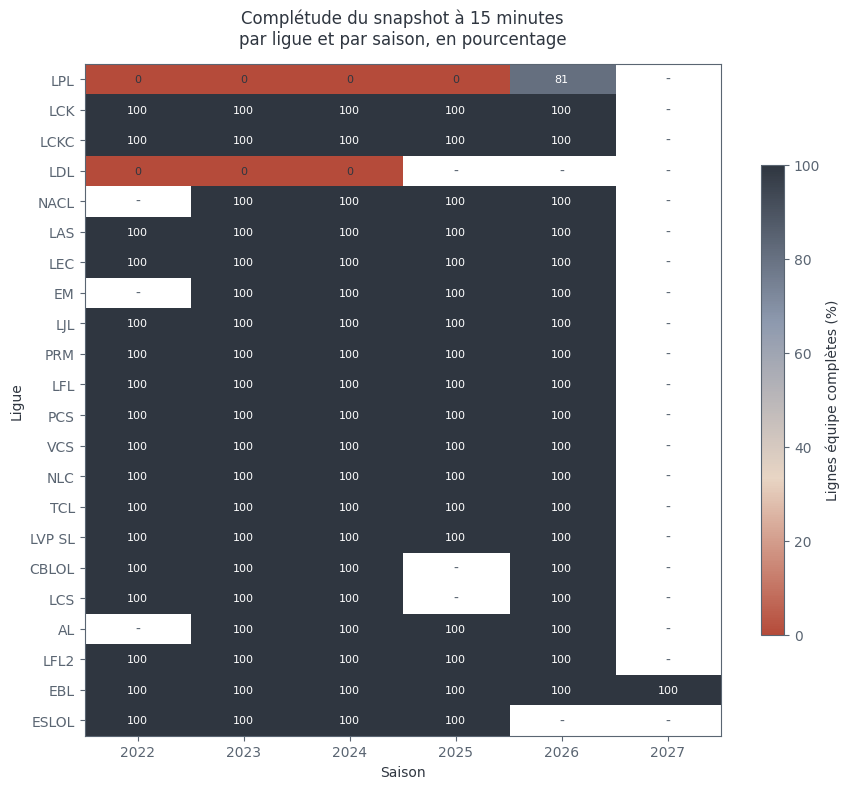

In [8]:
# Figure : complétude du snapshot à 15 minutes, par ligue et par saison.
top_ligues = resume_ligue.head(22).index
matrice = (
    oe[oe["league"].isin(top_ligues)]
    .pivot_table(index="league", columns="year", values="_at15_ok", aggfunc="mean")
    .mul(100)
)
ordre = [l for l in resume_ligue.head(22).index if l in matrice.index]
matrice = matrice.loc[ordre]

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(matrice.values, cmap=CMAP_ARDOISE, vmin=0, vmax=100, aspect="auto")

ax.set_xticks(range(len(matrice.columns)))
ax.set_xticklabels([int(c) for c in matrice.columns])
ax.set_yticks(range(len(matrice.index)))
ax.set_yticklabels(matrice.index)

for i in range(matrice.shape[0]):
    for j in range(matrice.shape[1]):
        v = matrice.values[i, j]
        if np.isnan(v):
            ax.text(j, i, "-", ha="center", va="center", color=PALETTE["secondary"])
        else:
            ax.text(j, i, f"{v:.0f}", ha="center", va="center",
                    color="white" if v > 55 else PALETTE["primary"], fontsize=8)

ax.set_title("Complétude du snapshot à 15 minutes\npar ligue et par saison, en pourcentage",
             pad=14, fontsize=12)
ax.set_xlabel("Saison")
ax.set_ylabel("Ligue")
fig.colorbar(im, ax=ax, label="Lignes équipe complètes (%)", shrink=0.7)
fig.tight_layout()
fig.savefig(config.FIGURES / "02_completude_at15_ligue_saison.png", dpi=150,
            facecolor=PALETTE["background"])
plt.show()

La lecture est nette : l'incomplétude n'est pas répartie au hasard. Elle se concentre sur des
ligues entières et des saisons entières, ce qui trahit un mode de collecte et non des
accidents ponctuels. Certaines ligues mineures n'ont jamais eu de relevé à 15 minutes,
d'autres en ont à partir d'une saison précise.

Cela confirme la décision de phase 0 : **filtrer sur la disponibilité mesurée, pas sur le nom
de la ligue**. Une ligue au snapshot complet reste dans le jeu, même mineure. Une ligue sans
snapshot en sort, même majeure. Le critère est vérifiable et se défend à l'oral,
contrairement à une exclusion par réputation.

In [9]:
table_flag = quality.completeness_flag_breakdown(oe)
desaccord_flag = int(table_flag.loc["complete", False]) if False in table_flag.columns else 0
print()
print(f"Lignes marquées 'complete' mais sans snapshot at15 exploitable : {desaccord_flag}")

at15_ok           False  True 
datacompleteness              
complete             30  92616
partial           11898      0

Lignes marquées 'complete' mais sans snapshot at15 exploitable : 30


Le drapeau et la réalité ne coïncident pas parfaitement, ce que la phase 0 avait anticipé.
Quelques dizaines de lignes sont déclarées complètes sans l'être sur les colonnes qui nous
intéressent. On se fie donc aux colonnes, et le drapeau reste un signal secondaire.

## 2. Unicité

Question : y a-t-il des doublons indésirables, et quelle est la vraie clé primaire ?

In [10]:
doublons_exacts = int(oe.duplicated().sum())
doublons_naifs = int(oe.duplicated(subset=["gameid", "teamid"]).sum())
teamid_manquant = int(oe["teamid"].isna().sum())
doublons_cle = int(oe[oe["teamid"].notna()].duplicated(subset=["gameid", "teamid"]).sum())

lignes_par_partie = oe.groupby("gameid").size()
joueurs_par_partie = oe_joueurs.groupby("gameid").size()

print(f"Lignes dupliquées à l'identique            : {doublons_exacts}")
print(f"teamid manquant                            : {teamid_manquant:,} "
      f"({100 * teamid_manquant / len(oe):.2f} %)")
print(f"Doublons gameid + teamid, test naïf        : {doublons_naifs}")
print(f"Doublons gameid + teamid, clé renseignée   : {doublons_cle}")
print()
print(f"Parties sans exactement 2 lignes équipe    : {int((lignes_par_partie != 2).sum())}")
print(f"Parties sans exactement 10 lignes joueur   : {int((joueurs_par_partie != 10).sum())}")
print()
print(f"teamname distincts : {oe['teamname'].nunique():,}")
print(f"teamid distincts   : {oe['teamid'].nunique():,}")

Lignes dupliquées à l'identique            : 0
teamid manquant                            : 1,800 (1.72 %)
Doublons gameid + teamid, test naïf        : 325
Doublons gameid + teamid, clé renseignée   : 0

Parties sans exactement 2 lignes équipe    : 0
Parties sans exactement 10 lignes joueur   : 0

teamname distincts : 1,405
teamid distincts   : 1,166


L'unicité est la dimension la plus saine du jeu de données. Aucune ligne dupliquée à
l'identique, exactement deux lignes équipe et dix lignes joueur par partie, sans une seule
exception sur plus de 52 000 parties.

Un piège méthodologique mérite d'être signalé. Le test naïf sur `gameid` + `teamid` remonte
des doublons qui n'en sont pas : `duplicated` traite deux `NaN` comme égaux, si bien que deux
équipes distinctes d'une même partie, toutes deux sans identifiant, passent pour un doublon.
Le test doit donc porter sur les seules lignes où la clé est renseignée.

Il y a par ailleurs plus de noms d'équipe que d'identifiants, ce qui s'explique par les
changements de nom en cours de carrière. Comme `teamname` ne sera jamais une feature et sert
uniquement à construire les variables de forme en phase 4, l'écart est à surveiller sans être
grave.

In [11]:
alias = (
    oe.dropna(subset=["teamid"])
      .groupby("teamid")["teamname"]
      .nunique()
      .sort_values(ascending=False)
)
print(f"Identifiants portant plus d'un nom : {int((alias > 1).sum()):,}")
print()
for tid in alias.head(3).index:
    noms = sorted(oe.loc[oe["teamid"] == tid, "teamname"].dropna().unique())
    print(f"  {tid[:26]:<28} {noms[:4]}")

Identifiants portant plus d'un nom : 0

  oe:team:005064b6157615d237   ['Team Coachify']
  oe:team:af8b66545ea6fd0b88   ['Team High Ground']
  oe:team:a9a549afd3c38f0864   ['Barcząca Esports']


## 3. Cohérence

Question : les formats et les conventions sont-ils uniformes ?

In [12]:
print("Inventaire des colonnes catégorielles clés")
for col in ["side", "datacompleteness", "position"]:
    valeurs = sorted(oe[col].dropna().unique().tolist())
    print(f"  {col:<18} {oe[col].nunique():>3} modalités : {valeurs[:6]}")

print()
noms = oe["teamname"].dropna()
print("Casse et espaces parasites sur les noms d'équipe :")
print(f"  noms avec espaces en bordure : {int((noms != noms.str.strip()).sum())}")
print(f"  noms distincts               : {noms.nunique():,}")
print(f"  après normalisation de casse : {noms.str.strip().str.lower().nunique():,}")

Inventaire des colonnes catégorielles clés
  side                 2 modalités : ['Blue', 'Red']
  datacompleteness     2 modalités : ['complete', 'partial']
  position             1 modalités : ['team']

Casse et espaces parasites sur les noms d'équipe :
  noms avec espaces en bordure : 0
  noms distincts               : 1,405
  après normalisation de casse : 1,405


### 3.1 La colonne `split` ne survit pas à la frontière 2025 / 2026

`split` figure dans `config.CATEGORICAL_FEATURES`. La phase 0 a écarté `league`, `year` et
`patch_major` parce que leurs modalités ne survivent pas au passage à 2026. Le même test doit
être appliqué à `split`.

In [13]:
modalites_train = set(oe.loc[oe["year"].isin(config.TRAIN_SEASONS), "split"].dropna())
modalites_test = set(oe.loc[oe["year"].isin(config.TEST_SEASONS), "split"].dropna())
inconnues = modalites_test - modalites_train

print(f"Modalités distinctes    : {oe['split'].nunique()}")
print(f"Valeurs manquantes      : {100 * oe['split'].isna().mean():.1f} %")
print(f"Modalités du train      : {len(modalites_train)}")
print(f"Modalités du test       : {len(modalites_test)}")
print(f"Absentes du train       : {len(inconnues)} -> {sorted(inconnues)}")
print()
print(f"Lignes portant une modalité jamais vue : {int(oe['split'].isin(inconnues).sum()):,}")
print()
print("Dix modalités les plus fréquentes :")
print(oe["split"].value_counts().head(10).to_string())

Modalités distinctes    : 32


Valeurs manquantes      : 19.8 %
Modalités du train      : 29
Modalités du test       : 14
Absentes du train       : 3 -> ['Lock-In', 'Rounds 3-4', 'Versus']

Lignes portant une modalité jamais vue : 860

Dix modalités les plus fréquentes :
split
Spring        25542
Summer        25006
Split 2        7100
Split 1        6700
Winter         4828
Split 3        2454
Champ 1        1852
Rounds 1-2     1818
Champ 2        1174
Closing         910


Le verdict est le même que pour `league`. Un cinquième des lignes n'a pas de valeur, les
modalités sont propres à chaque circuit, et trois d'entre elles n'apparaissent qu'en 2026.

`OneHotEncoder(handle_unknown="ignore")` ne planterait pas : il encoderait ces lignes en bloc
de zéros, donc perdrait l'information en silence, ce qui est pire qu'une erreur franche.

Décision retenue : retirer `split` de `CATEGORICAL_FEATURES` et conserver `playoffs`, qui
porte la même opposition saison régulière contre phase finale sous une forme binaire stable.

In [14]:
# Cohérence interne : les écarts sont-ils bien la différence des deux camps ?
base = oe.dropna(subset=["goldat15", "opp_goldat15", "golddiffat15"])

controles_arithmetiques = []
for gauche, droite, diff in [
    ("goldat15", "opp_goldat15", "golddiffat15"),
    ("xpat15", "opp_xpat15", "xpdiffat15"),
    ("csat15", "opp_csat15", "csdiffat15"),
]:
    incoherent = int((~np.isclose(base[gauche] - base[droite], base[diff])).sum())
    controles_arithmetiques.append(
        {"controle": f"{diff} = {gauche} - {droite}", "lignes_incoherentes": incoherent}
    )

print(pd.DataFrame(controles_arithmetiques).to_string(index=False))
print()

miroir = base.groupby("gameid")["golddiffat15"].sum()
print(f"Parties dont les deux golddiffat15 ne s'annulent pas : "
      f"{int((~np.isclose(miroir, 0)).sum()):,} sur {len(miroir):,}")

                              controle  lignes_incoherentes
golddiffat15 = goldat15 - opp_goldat15                    0
      xpdiffat15 = xpat15 - opp_xpat15                    0
      csdiffat15 = csat15 - opp_csat15                    0

Parties dont les deux golddiffat15 ne s'annulent pas : 0 sur 46,308


L'arithmétique interne est parfaitement cohérente : aucun écart mal calculé, et les deux
lignes d'une même partie sont bien le miroir l'une de l'autre. C'est un signal de confiance
important sur la source.

Cela établit au passage que `golddiffat15` n'apporte rien de plus que le couple `goldat15` et
`opp_goldat15`. La phase 4 pourra n'en conserver qu'une forme, sans aucune perte
d'information, ce qui allègera la matrice de features.

### 3.2 `year` est une étiquette de saison, pas une année civile

Le split du projet repose sur `year`. Il faut donc savoir si cette colonne dit bien ce qu'on
croit qu'elle dit.

In [15]:
desaccord_annee = oe[oe["year"] != oe["date"].dt.year]
hors_perimetre = oe[~oe["year"].isin(config.SEASONS)]

print(f"Lignes où year diffère de l'année de la date : {len(desaccord_annee):,} "
      f"({100 * len(desaccord_annee) / len(oe):.1f} %)")
print(f"Lignes dont year sort des saisons attendues  : {len(hors_perimetre)}")
print()
print("Croisement étiquette de saison x année civile de la date :")
print(desaccord_annee.groupby([desaccord_annee["year"],
                               desaccord_annee["date"].dt.year]).size().to_string())
print()
print("Mois de jeu de ces lignes :")
print(desaccord_annee["date"].dt.month.value_counts().sort_index().to_string())

Lignes où year diffère de l'année de la date : 2,712 (2.6 %)
Lignes dont year sort des saisons attendues  : 10

Croisement étiquette de saison x année civile de la date :
year  date
2023  2022    692
      2024     36
2024  2023    752
2025  2024    726
2026  2025    496
2027  2026     10

Mois de jeu de ces lignes :
date
1       36
6       12
7      114
8      252
9     1378
10     328
11     368
12     224


Le croisement est sans ambiguïté : ces lignes se jouent très majoritairement entre septembre
et décembre, et portent l'étiquette de la saison **suivante**. Ce ne sont pas des erreurs. Les
circuits professionnels ouvrent leur saison à l'automne de l'année civile précédente, et
Oracle's Elixir étiquette la saison, pas l'année du calendrier.

Le problème n'est donc pas la qualité de la colonne, mais l'usage qu'on veut en faire.
Découper le jeu sur `year` reviendrait à découper sur une étiquette de compétition alors que
l'objectif est un découpage **chronologique**. Des parties jouées en décembre 2025 se
retrouveraient dans le jeu de test parce qu'elles appartiennent à la saison 2026, tandis que
des parties postérieures resteraient dans l'entraînement. L'ordre temporel serait rompu là
même où on cherche à le garantir, et les 10 lignes étiquetées 2027 ne tomberaient ni d'un côté
ni de l'autre.

Décision : **découper sur la date**, avec une frontière au 1er janvier 2026. Le critère est
strictement temporel, ne laisse aucune ligne orpheline, et correspond exactement à ce que le
split chronologique est censé simuler.

## 4. Exactitude

Question : les valeurs sont-elles plausibles ?

C'est ici que se trouve le problème le plus grave du jeu de données.

In [16]:
colonnes_at15 = [c for c in config.GAMESTATE_AT_15 if c in oe.columns]
print(oe[colonnes_at15].describe().T[["min", "25%", "50%", "75%", "max"]].round(1).to_string())

                      min      25%      50%      75%      max
goldat15          18800.0  23905.0  25054.0  26400.0  37387.0
xpat15            20358.0  29108.0  30154.0  31365.0  38606.0
csat15              289.0    492.0    519.0    544.0    665.0
opp_goldat15      18800.0  23905.0  25054.0  26400.0  37387.0
opp_xpat15        20358.0  29108.0  30154.0  31365.0  38606.0
opp_csat15          289.0    492.0    519.0    544.0    665.0
golddiffat15     -17056.0  -1827.0      0.0   1827.0  17056.0
xpdiffat15       -11556.0  -1298.0      0.0   1298.0  11556.0
csdiffat15         -233.0    -27.0      0.0     27.0    233.0
killsat15             0.0      2.0      4.0      6.0     29.0
assistsat15           0.0      3.0      6.0     10.0     57.0
deathsat15            0.0      2.0      4.0      6.0     29.0
opp_killsat15         0.0      2.0      4.0      6.0     29.0
opp_assistsat15       0.0      3.0      6.0     10.0     57.0
opp_deathsat15        0.0      2.0      4.0      6.0     29.0
firstblo

In [17]:
# Bornes connues des règles du jeu, indépendantes des données observées.
BORNES_METIER = {
    "goldat15": (10000, 40000, "or cumulé d'une équipe à 15 minutes"),
    "xpat15": (10000, 45000, "expérience cumulée d'une équipe"),
    "csat15": (100, 800, "sbires tués par l'équipe"),
    "killsat15": (0, 40, "éliminations de l'équipe"),
    "turretplates": (0, 15, "3 tourelles extérieures adverses x 5 plaques"),
}

lignes = []
for col, (bas, haut, motif) in BORNES_METIER.items():
    if col not in oe.columns:
        continue
    serie = oe[col].dropna()
    lignes.append({
        "colonne": col, "borne_basse": bas, "borne_haute": haut,
        "observe_min": serie.min(), "observe_max": serie.max(),
        "lignes_hors_bornes": int(((serie < bas) | (serie > haut)).sum()),
        "justification": motif,
    })

controle_bornes = pd.DataFrame(lignes)
print(controle_bornes.to_string(index=False))

     colonne  borne_basse  borne_haute  observe_min  observe_max  lignes_hors_bornes                                justification
    goldat15        10000        40000      18800.0      37387.0                   0          or cumulé d'une équipe à 15 minutes
      xpat15        10000        45000      20358.0      38606.0                   0              expérience cumulée d'une équipe
      csat15          100          800        289.0        665.0                   0                     sbires tués par l'équipe
   killsat15            0           40          0.0         29.0                   0                     éliminations de l'équipe
turretplates            0           15          0.0         45.0               10554 3 tourelles extérieures adverses x 5 plaques


### 4.1 `turretplates` change d'échelle entre l'entraînement et le test

Une seule colonne sort de ses bornes, et pas d'un peu. Le plaquage ne concerne que les trois
tourelles extérieures, à cinq plaques chacune : une équipe ne peut pas en prendre plus de
quinze. Or la colonne monte à 45.

Le détail qui transforme une curiosité en danger est le calendrier de cette dérive.

In [18]:
print(oe.groupby("year")["turretplates"].agg(
    mediane="median", maximum="max",
    pct_sup_15=lambda s: round(100 * (s > 15).mean(), 1),
).to_string())

      mediane  maximum  pct_sup_15
year                              
2022      4.0     15.0         0.0
2023      4.0     15.0         0.0
2024      4.0     15.0         0.0
2025      4.0     15.0         0.0
2026     23.0     45.0        61.0
2027     30.0     45.0        80.0


La rupture tombe exactement sur la frontière du split chronologique. De 2022 à 2025 la colonne
respecte son maximum de 15. En 2026 elle atteint 45 et dépasse 15 sur près des deux tiers des
lignes.

**Conséquence directe sur la modélisation.** `turretplates` figure dans
`config.NUMERIC_FEATURES`. Un modèle entraîné sur 2022-2025 n'a jamais vu de valeur supérieure
à 15, et un `StandardScaler` ajusté sur ces saisons projetterait 2026 très loin de la plage
apprise. Le modèle ne planterait pas : il se tromperait silencieusement sur toute la saison de
test, ce qui est le pire des deux mondes.

Trois options pour la phase 3, par ordre de préférence.

1. **Retirer la colonne des features.** Simple, sans risque, et l'information est en partie
   redondante avec l'écart d'or.
2. La normaliser par saison, en rang ou en centile, ce qui absorbe le changement d'échelle
   mais complique l'explication en soutenance.
3. La plafonner à 15, ce qui écrase l'information de 2026 sans la corriger.

Décision retenue : option 1, avec l'option 2 en repli si la phase 5 montre que les plaques
portent un signal fort.

In [19]:
# Le même test, appliqué à toutes les colonnes d'état de jeu : qui d'autre dérive ?
train = oe[oe["year"].isin(config.TRAIN_SEASONS)]
test = oe[oe["year"].isin(config.TEST_SEASONS)]

lignes = []
for col in colonnes_at15:
    a, b = train[col].dropna(), test[col].dropna()
    if a.empty or b.empty:
        continue
    # Une binaire se compare en moyenne : sa médiane ne veut rien dire.
    binaire = set(a.unique()) <= {0, 1}
    ref_a, ref_b = (a.mean(), b.mean()) if binaire else (a.median(), b.median())
    derive = 100 * (ref_b - ref_a) / abs(ref_a) if ref_a else np.nan
    lignes.append({
        "colonne": col, "type": "binaire" if binaire else "continue",
        "ref_train": round(ref_a, 2), "ref_test": round(ref_b, 2),
        "derive_pct": round(derive, 1) if pd.notna(derive) else None,
        "max_train": a.max(), "max_test": b.max(),
    })

derive_table = pd.DataFrame(lignes)
derive_table["alerte"] = (
    (derive_table["max_test"] > 1.5 * derive_table["max_train"])
    | (derive_table["derive_pct"].abs() > 10)
)
print(derive_table.to_string(index=False))
print()
print("Colonnes en alerte :", derive_table.loc[derive_table["alerte"], "colonne"].tolist())

         colonne     type  ref_train  ref_test  derive_pct  max_train  max_test  alerte
        goldat15 continue    24753.0  26413.00         6.7    37387.0   37358.0   False
          xpat15 continue    29820.0  32731.00         9.8    36444.0   38606.0   False
          csat15 continue      513.0    552.00         7.6      636.0     665.0   False
    opp_goldat15 continue    24753.0  26413.00         6.7    37387.0   37358.0   False
      opp_xpat15 continue    29820.0  32731.00         9.8    36444.0   38606.0   False
      opp_csat15 continue      513.0    552.00         7.6      636.0     665.0   False
    golddiffat15 continue        0.0      0.00         NaN    17056.0   14704.0   False
      xpdiffat15 continue        0.0      0.00         NaN    11060.0   11556.0   False
      csdiffat15 continue        0.0      0.00         NaN      223.0     233.0   False
       killsat15 continue        4.0      4.00         0.0       28.0      29.0   False
     assistsat15 continue       

Au-delà de `turretplates`, l'or, l'expérience et les sbires à 15 minutes progressent de 7 à
10 % entre l'entraînement et le test. Ce n'est pas une anomalie mais une **dérive de méta** :
le jeu s'accélère, les équipes sont plus riches au même instant.

Cette dérive est l'argument qui justifie le split chronologique. Un split aléatoire l'aurait
dissimulée en mélangeant les saisons des deux côtés de la frontière, et aurait produit un
score flatteur mais faux.

Elle motive aussi la feature `ecart_or_normalise` prévue en phase 4, qui rapporte l'écart d'or
à la médiane du patch : un avantage de 2 000 or ne vaut pas la même chose en 2022 et en 2026.

In [20]:
# Outliers par IQR sur les colonnes continues destinées à devenir des features.
lignes = []
for col in ["golddiffat15", "xpdiffat15", "csdiffat15", "killsat15", "deathsat15"]:
    serie = oe[col].dropna()
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    bas, haut = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    hors = int(((serie < bas) | (serie > haut)).sum())
    lignes.append({"colonne": col, "q1": round(q1, 1), "q3": round(q3, 1),
                   "borne_basse": round(bas, 1), "borne_haute": round(haut, 1),
                   "outliers": hors, "pct": round(100 * hors / len(serie), 2)})

print(pd.DataFrame(lignes).to_string(index=False))

     colonne      q1     q3  borne_basse  borne_haute  outliers  pct
golddiffat15 -1827.0 1827.0      -7308.0       7308.0      2250 2.43
  xpdiffat15 -1298.0 1298.0      -5192.0       5192.0      2144 2.31
  csdiffat15   -27.0   27.0       -108.0        108.0      1362 1.47
   killsat15     2.0    6.0         -4.0         12.0      1624 1.75
  deathsat15     2.0    6.0         -4.0         12.0      1649 1.78


Les valeurs extrêmes détectées par l'IQR sont des **parties déséquilibrées**, pas des erreurs
de saisie. Un écart de 10 000 or à la quinzième minute existe réellement, et c'est même le cas
le plus informatif pour prédire l'issue.

Décision : aucun retrait d'outlier. Les supprimer reviendrait à retirer du jeu les parties les
plus faciles à prédire, et ferait chuter artificiellement la performance mesurée. Compromis
assumé, à mentionner en soutenance.

In [21]:
courtes = oe[oe["gamelength"] < 900]
courtes_avec_at15 = int(courtes[config.REQUIRED_AT15].notna().all(axis=1).sum())

vainqueurs = oe.groupby("gameid")["result"].sum()
sans_vainqueur = int((vainqueurs != 1).sum())

print(f"Parties de moins de 15 minutes              : {len(courtes):,}")
print(f"  dont porteuses d'un snapshot at15 complet : {courtes_avec_at15}")
print(f"Parties sans vainqueur unique               : {sans_vainqueur}")
print(f"Valeurs de result hors 0/1                  : {int((~oe['result'].isin([0, 1])).sum())}")
print(f"Durée de partie minimale observée           : {oe['gamelength'].min():.0f} s")

Parties de moins de 15 minutes              : 10
  dont porteuses d'un snapshot at15 complet : 0
Parties sans vainqueur unique               : 3
Valeurs de result hors 0/1                  : 0
Durée de partie minimale observée           : 201 s


Deux enseignements. Aucune partie de moins de quinze minutes ne porte de snapshot à quinze
minutes : la source est logiquement cohérente, elle n'invente pas de données.

En revanche, trois parties n'ont aucun vainqueur, leurs deux lignes portant `result` à 0. Ce
sont des parties annulées dont le résultat n'a jamais été consolidé. Six lignes inutilisables
en apprentissage supervisé, à supprimer par paires en phase 3.

## 5. Fraîcheur

Question : les données sont-elles assez récentes, et couvrent-elles la période annoncée ?

In [22]:
aujourd_hui = pd.Timestamp("2026-09-07")

print(f"Première partie     : {oe['date'].min():%Y-%m-%d}")
print(f"Dernière partie     : {oe['date'].max():%Y-%m-%d}")
print(f"Retard de la source : {(aujourd_hui - oe['date'].max()).days} jour(s)")
print()

par_mois = oe.set_index("date").resample("ME").size()
print(f"Mois couverts : {len(par_mois)} | mois sans aucune partie : {int((par_mois == 0).sum())}")
print()
print("Lignes équipe par saison :")
print(oe["year"].value_counts().sort_index().to_string())

Première partie     : 2022-01-10
Dernière partie     : 2026-09-06
Retard de la source : 0 jour(s)



Mois couverts : 57 | mois sans aucune partie : 0

Lignes équipe par saison :
year
2022    24366
2023    22188
2024    20380
2025    20312
2026    17288
2027       10


In [23]:
print("Fenêtre calendaire réellement couverte, par saison :")
for annee in config.SEASONS:
    sous = oe[oe["date"].dt.year == annee]
    if len(sous):
        print(f"  {annee} : {sous['date'].min():%d %b} au {sous['date'].max():%d %b}, "
              f"{len(sous):,} lignes")

print()
print("Saison 2026, volume par mois :")
print(oe[oe["date"].dt.year == 2026].set_index("date").resample("ME").size().to_string())

Fenêtre calendaire réellement couverte, par saison :
  2022 : 10 Jan au 27 Dec, 25,058 lignes
  2023 : 10 Jan au 31 Dec, 22,212 lignes
  2024 : 01 Jan au 08 Dec, 20,390 lignes
  2025 : 11 Jan au 29 Dec, 20,082 lignes
  2026 : 08 Jan au 06 Sep, 16,802 lignes

Saison 2026, volume par mois :


date
2026-01-31    1400
2026-02-28    2020
2026-03-31    1434
2026-04-30    2926
2026-05-31    3022
2026-06-30    1118
2026-07-31    1724
2026-08-31    2656
2026-09-30     502
Freq: ME


La source est à jour : la dernière partie date de la veille, ce qui confirme la mise à jour
quotidienne annoncée par Oracle's Elixir. Aucun mois n'est vide sur les cinq saisons.

**Mais le jeu de test est une saison tronquée.** Les données s'arrêtent au 6 septembre 2026,
alors que les saisons 2022 à 2025 courent jusqu'en novembre ou décembre. Il manque la fin de
saison 2026, et surtout les Worlds, qui se jouent en octobre.

Deux conséquences à énoncer plutôt qu'à subir. Le jeu de test est plus petit qu'une saison
complète, ce qui élargit l'intervalle de confiance des scores. Et sa composition penche vers
la saison régulière, alors que les saisons d'entraînement contiennent leurs phases finales et
leur tournoi mondial. Comparer un score 2026 à un score 2025 revient donc à comparer une
saison partielle à une saison entière.

## 6. Synthèse et notation

Chaque dimension reçoit une note sur 5. Les notes sont volontairement sévères là où le
problème menace la phase de modélisation, qui pèse 25 points sur 100.

In [24]:
SYNTHESE = [
    {"dimension": "Complétude", "note": 3,
     "probleme": f"{100 * (~at15_ok).mean():.1f} % des lignes équipe sans snapshot à 15 min, "
                 f"{int((manquants['criticite'] == 'haute').sum())} colonnes au-dessus de 30 % de manquants",
     "priorite": "haute"},
    {"dimension": "Unicité", "note": 5,
     "probleme": f"Aucun doublon, structure parfaite. Seule réserve : {teamid_manquant:,} lignes sans teamid",
     "priorite": "basse"},
    {"dimension": "Cohérence", "note": 3,
     "probleme": f"split ingérable ({oe['split'].nunique()} modalités, {len(inconnues)} absentes du train). "
                 f"year est une étiquette de saison, pas une année civile. Arithmétique interne parfaite",
     "priorite": "haute"},
    {"dimension": "Exactitude", "note": 2,
     "probleme": "turretplates change d'échelle en 2026 (max 15 vers 45) sur la frontière du split, "
                 f"{sans_vainqueur} parties sans vainqueur",
     "priorite": "haute"},
    {"dimension": "Fraîcheur", "note": 4,
     "probleme": "Source à jour et sans trou mensuel, mais 2026 est tronquée au 6 septembre, sans Worlds",
     "priorite": "moyenne"},
]

synthese = pd.DataFrame(SYNTHESE)
score_global = synthese["note"].mean()

print(synthese.to_string(index=False))
print()
print(f"Score de qualité global : {score_global:.1f} / 5")

 dimension  note                                                                                                                                   probleme priorite
Complétude     3                                                11.4 % des lignes équipe sans snapshot à 15 min, 17 colonnes au-dessus de 30 % de manquants    haute
   Unicité     5                                                                Aucun doublon, structure parfaite. Seule réserve : 1,800 lignes sans teamid    basse
 Cohérence     3 split ingérable (32 modalités, 3 absentes du train). year est une étiquette de saison, pas une année civile. Arithmétique interne parfaite    haute
Exactitude     2                                 turretplates change d'échelle en 2026 (max 15 vers 45) sur la frontière du split, 3 parties sans vainqueur    haute
 Fraîcheur     4                                                     Source à jour et sans trou mensuel, mais 2026 est tronquée au 6 septembre, sans Worlds  moyenne

Score de 

## 7. Priorisation des corrections

La matrice du guide croise l'impact du problème et la difficulté de sa correction.

In [25]:
ACTIONS = [
    {"probleme": "Colonnes post-partie omniprésentes", "impact": "eleve", "difficulte": "facile",
     "priorite": 1, "action": "Supprimer config.LEAKY_COLUMNS", "phase": 3},
    {"probleme": "turretplates change d'échelle en 2026", "impact": "eleve", "difficulte": "facile",
     "priorite": 1, "action": "Retirer la colonne de NUMERIC_FEATURES", "phase": 3},
    {"probleme": "Snapshot at15 absent sur 11 % des lignes", "impact": "eleve", "difficulte": "facile",
     "priorite": 1, "action": "Supprimer les parties par paires (quality.drop_incomplete_games)", "phase": 3},
    {"probleme": "split ne survit pas à la frontière", "impact": "eleve", "difficulte": "facile",
     "priorite": 1, "action": "Retirer split de CATEGORICAL_FEATURES, garder playoffs", "phase": 3},
    {"probleme": "3 parties sans vainqueur", "impact": "eleve", "difficulte": "facile",
     "priorite": 1, "action": "Supprimer les 6 lignes par paires", "phase": 3},
    {"probleme": "year est une étiquette de saison, pas une année civile", "impact": "eleve",
     "difficulte": "facile", "priorite": 1,
     "action": "Découper sur la date au 1er janvier 2026, jamais sur year", "phase": 3},
    {"probleme": "Dérive de méta sur l'or et l'expérience", "impact": "eleve", "difficulte": "difficile",
     "priorite": 2, "action": "Construire ecart_or_normalise, rapporté à la médiane du patch", "phase": 4},
    {"probleme": "2026 tronquée, sans Worlds", "impact": "eleve", "difficulte": "difficile",
     "priorite": 2, "action": "Non corrigeable, à énoncer comme limite d'évaluation", "phase": 9},
    {"probleme": f"teamid manquant sur {teamid_manquant:,} lignes", "impact": "faible",
     "difficulte": "facile", "priorite": 3,
     "action": "Se rabattre sur teamname pour les variables de forme", "phase": 4},
    {"probleme": "Région CEI réduite à 32 lignes", "impact": "faible", "difficulte": "facile",
     "priorite": 3, "action": "Regrouper les régions rares", "phase": 4},
    {"probleme": "Outliers d'écart d'or", "impact": "faible", "difficulte": "difficile",
     "priorite": 4, "action": "Ne rien faire, ce sont de vraies parties déséquilibrées", "phase": 3},
]

actions = pd.DataFrame(ACTIONS).sort_values(["priorite", "probleme"]).reset_index(drop=True)
print(actions.to_string(index=False))

                                              probleme impact difficulte  priorite                                                           action  phase
                              3 parties sans vainqueur  eleve     facile         1                                Supprimer les 6 lignes par paires      3
                    Colonnes post-partie omniprésentes  eleve     facile         1                                   Supprimer config.LEAKY_COLUMNS      3
              Snapshot at15 absent sur 11 % des lignes  eleve     facile         1 Supprimer les parties par paires (quality.drop_incomplete_games)      3
                    split ne survit pas à la frontière  eleve     facile         1           Retirer split de CATEGORICAL_FEATURES, garder playoffs      3
                 turretplates change d'échelle en 2026  eleve     facile         1                           Retirer la colonne de NUMERIC_FEATURES      3
year est une étiquette de saison, pas une année civile  eleve     faci

Les six chantiers de priorité 1 partagent une propriété commode : tous à fort impact, tous
faciles à corriger. Ils tiennent en quelques filtres de phase 3 et lèvent l'essentiel du
risque.

La priorité 2 regroupe ce qui demande un vrai travail de construction en phase 4, ou ce qui ne
se corrige pas du tout et doit simplement être annoncé.

## 8. Génération du rapport de diagnostic

Le rapport est écrit à partir des variables calculées plus haut. Aucun chiffre n'est recopié à
la main, ce qui garantit que `docs/rapport_diagnostic.md` ne peut pas diverger du notebook
quand les données seront mises à jour.

In [26]:
def tableau_markdown(df):
    entete = "| " + " | ".join(str(c) for c in df.columns) + " |"
    separateur = "|" + "|".join(["---"] * len(df.columns)) + "|"
    corps = ["| " + " | ".join(str(v) for v in row) + " |"
             for row in df.itertuples(index=False)]
    return "\n".join([entete, separateur] + corps)


pire_ligues = (
    resume_ligue.sort_values("lignes_perdues", ascending=False).head(8).reset_index()
    .rename(columns={"league": "Ligue", "lignes": "Lignes",
                     "taux_at15": "Complétude at15 (%)", "lignes_perdues": "Lignes perdues"})
)
synthese_md = synthese.rename(columns={
    "dimension": "Dimension", "note": "Note sur 5",
    "probleme": "Principaux problèmes", "priorite": "Priorité"})
actions_md = actions.rename(columns={
    "probleme": "Problème", "impact": "Impact", "difficulte": "Difficulté",
    "priorite": "Priorité", "action": "Action retenue", "phase": "Phase"})

max_plates_2026 = oe.loc[oe["year"] == 2026, "turretplates"].max()
pct_plates_2026 = 100 * (oe.loc[oe["year"] == 2026, "turretplates"] > 15).mean()

rapport = f"""# Rapport de diagnostic qualité

Phase 2 du projet final Machine Learning. Document généré par
`notebooks/02_eda_diagnostique.ipynb`, à ne pas éditer à la main.

Périmètre : lignes équipe d'Oracle's Elixir, saisons {min(config.SEASONS)} à {max(config.SEASONS)}.
Volume analysé : {len(oe):,} lignes équipe, {oe['gameid'].nunique():,} parties, {oe.shape[1] - 1} colonnes.

## Score de qualité global

**{score_global:.1f} / 5**

{tableau_markdown(synthese_md)}

## 1. Complétude

{100 * at15_ok.mean():.1f} % des lignes équipe disposent d'un snapshot complet à la minute 15,
sur les colonnes {', '.join(f'`{c}`' for c in config.REQUIRED_AT15)}.

La règle d'inclusion retenue en phase 0 impose que **les deux** lignes d'une partie soient
complètes, faute de quoi la partie entière est écartée. Supprimer une ligne isolée
déséquilibrerait la cible, dont le 50/50 est la propriété la plus utile de ce jeu de données.

| Mesure | Valeur |
|---|---|
| Lignes équipe complètes | {int(at15_ok.sum()):,} |
| Lignes équipe incomplètes | {perte_ligne:,} |
| Parties entièrement exploitables | {int(parties_completes.sum()):,} sur {len(parties_completes):,} |
| Lignes réellement perdues, par paires | {perte_partie:,} |
| Surcoût de la règle des deux lignes | {perte_partie - perte_ligne:,} lignes |

{int((manquants['criticite'] == 'haute').sum())} colonnes dépassent 30 % de valeurs manquantes,
dont {len(vides)} sont vides à 100 %. Ces dernières ne sont pas un défaut : ce sont des champs de
ligne joueur, structurellement absents des lignes équipe.

L'incomplétude n'est pas aléatoire, elle se concentre par ligue et par saison. Voir
`figures/02_completude_at15_ligue_saison.png`.

{tableau_markdown(pire_ligues)}

Cela confirme la décision de phase 0 : filtrer sur la disponibilité **mesurée** du snapshot,
jamais sur le nom d'une ligue.

Aucune imputation n'est réalisée à ce stade, conformément au guide. Elle interviendra en
phase 7, dans un `Pipeline` ajusté sur le seul jeu d'entraînement.

## 2. Unicité

| Contrôle | Résultat |
|---|---|
| Lignes dupliquées à l'identique | {doublons_exacts} |
| Doublons sur gameid + teamid, clé renseignée | {doublons_cle} |
| Parties n'ayant pas exactement 2 lignes équipe | {int((lignes_par_partie != 2).sum())} |
| Parties n'ayant pas exactement 10 lignes joueur | {int((joueurs_par_partie != 10).sum())} |
| Lignes sans teamid | {teamid_manquant:,} |

Dimension la plus saine du jeu de données. Piège méthodologique à signaler : `duplicated`
traite deux `NaN` comme égaux, si bien qu'un test naïf sur `gameid` + `teamid` remonte
{doublons_naifs} faux doublons, qui sont en réalité des parties valides opposant deux équipes
distinctes dépourvues d'identifiant.

## 3. Cohérence

L'arithmétique interne est exacte : `golddiffat15`, `xpdiffat15` et `csdiffat15` valent toujours
la différence entre les deux camps, et les deux lignes d'une partie sont bien le miroir l'une de
l'autre. La source est fiable sur ce plan, et `golddiffat15` est donc redondant avec le couple
`goldat15` et `opp_goldat15`.

Deux problèmes réels.

**La colonne `split` ne survit pas au split chronologique.** {oe['split'].nunique()} modalités,
{100 * oe['split'].isna().mean():.1f} % de valeurs manquantes, et {len(inconnues)} modalités
présentes en 2026 mais absentes de l'entraînement ({', '.join(sorted(inconnues))}).
`OneHotEncoder(handle_unknown="ignore")` les encoderait en bloc de zéros, donc perdrait
l'information sans lever d'erreur. Action : retirer `split` de `CATEGORICAL_FEATURES` et
conserver `playoffs`.

**`year` est une étiquette de saison, pas une année civile.** {len(desaccord_annee):,} lignes
({100 * len(desaccord_annee) / len(oe):.1f} %) portent un `year` différent de l'année de leur
date. Ce ne sont pas des erreurs : ces parties se jouent entre septembre et décembre et portent
l'étiquette de la saison suivante, parce que les circuits ouvrent leur saison à l'automne
précédent. À cela s'ajoutent {len(hors_perimetre)} lignes étiquetées 2027.

Le défaut n'est donc pas dans la colonne mais dans l'usage qu'on voudrait en faire. Découper sur
`year` reviendrait à découper sur une étiquette de compétition alors que l'objectif est un
découpage chronologique : des parties de décembre 2025 basculeraient dans le test tandis que des
parties postérieures resteraient dans l'entraînement, rompant l'ordre temporel là même où on
cherche à le garantir. Action : **découper sur la date**, frontière au 1er janvier 2026.

## 4. Exactitude

Dimension la plus faible, et porteuse du risque principal du projet.

**`turretplates` change d'échelle exactement sur la frontière du split.** Le maximum théorique
est de 15, soit trois tourelles extérieures à cinq plaques. De 2022 à 2025 la colonne le
respecte. En 2026 elle atteint {max_plates_2026:.0f} et dépasse 15 sur {pct_plates_2026:.0f} %
des lignes.

Cette colonne figurait dans `config.NUMERIC_FEATURES` au moment du diagnostic, et la phase 3
l'en a retirée sur la base de ce constat. Un modèle entraîné sur 2022-2025 n'a jamais
vu de telles valeurs, et un `StandardScaler` ajusté sur ces saisons projetterait 2026 hors de la
plage apprise. Le modèle ne planterait pas, il se tromperait en silence sur toute la saison de
test. Action : retirer la colonne des features.

**Dérive de méta.** L'or, l'expérience et les sbires à 15 minutes progressent de 7 à 10 % entre
l'entraînement et le test. Ce n'est pas une erreur mais une évolution réelle du jeu. Elle
justifie le split chronologique, qu'un split aléatoire aurait masqué, et motive la feature
`ecart_or_normalise` prévue en phase 4.

**Outliers.** Les valeurs extrêmes d'écart d'or sont de vraies parties déséquilibrées. Décision
assumée : aucun retrait, sous peine de supprimer les parties les plus faciles à prédire et de
dégrader artificiellement la performance mesurée.

**{sans_vainqueur} parties n'ont aucun vainqueur**, leurs deux lignes portant `result` à 0. Six
lignes à supprimer par paires.

Contrôle rassurant : aucune des {len(courtes)} parties de moins de quinze minutes ne porte de
snapshot à quinze minutes. La source n'invente pas de données.

## 5. Fraîcheur

| Mesure | Valeur |
|---|---|
| Première partie | {oe['date'].min():%Y-%m-%d} |
| Dernière partie | {oe['date'].max():%Y-%m-%d} |
| Retard de la source | {(aujourd_hui - oe['date'].max()).days} jour(s) |
| Mois sans aucune partie | {int((par_mois == 0).sum())} |

La source est à jour et sans trou mensuel. En revanche **la saison de test est tronquée** : 2026
s'arrête au 6 septembre, alors que les saisons d'entraînement vont jusqu'en novembre ou
décembre. Il manque la fin de saison et les Worlds.

Deux conséquences à annoncer en soutenance. Le jeu de test est plus petit qu'une saison
complète, ce qui élargit l'intervalle de confiance des scores. Et il penche vers la saison
régulière, alors que les saisons d'entraînement contiennent leurs phases finales.

## 6. Priorisation des corrections

{tableau_markdown(actions_md)}

Les chantiers de priorité 1 sont tous à fort impact et faciles à corriger. Ils tiennent en
quelques filtres de phase 3 et lèvent l'essentiel du risque.

## 7. Réponses aux questions de réflexion

**Le problème le plus surprenant.** Le changement d'échelle de `turretplates` en 2026. Une
colonne d'apparence anodine, dont la définition change précisément à la frontière entre
l'entraînement et le test, et qui aurait dégradé le modèle sans provoquer la moindre erreur.
C'est le type de défaut qu'un contrôle de valeurs manquantes ne voit pas et qu'un contrôle de
bornes métier attrape immédiatement.

**Le problème à corriger en priorité.** Les colonnes post-partie. Elles sont majoritaires parmi
les 165 colonnes et contiennent le résultat, directement ou non. Les laisser passer produirait
un modèle à plus de 95 % d'exactitude, sans aucune valeur, et plafonnerait la phase de
modélisation à 8 sur 25.

**L'origine des problèmes.** Presque tous viennent de la collecte et de l'évolution du jeu, pas
d'erreurs de saisie. Le snapshot manquant reflète l'absence d'instrumentation sur certaines
ligues mineures. Le changement de `turretplates` suit une modification des règles du jeu. Les
modalités de `split` reflètent l'organisation propre à chaque circuit. La seule erreur
véritable est celle des trois parties sans vainqueur.

**Ce qui ne sera pas corrigé.** Les outliers d'écart d'or, parce que ce sont de vraies parties.
Les noms d'équipe multiples pour un même identifiant, parce que `teamname` n'est jamais une
feature. Et la troncature de 2026, parce qu'elle n'est pas corrigeable : elle sera énoncée
comme une limite de l'évaluation.
"""

chemin_rapport = config.DOCS / "rapport_diagnostic.md"
chemin_rapport.write_text(rapport, encoding="utf-8")
print(f"Rapport écrit : {chemin_rapport}")
print(f"{len(rapport):,} caractères")

Rapport écrit : E:\LWP(LoLWinPrediciton)\lol-win-prediction\docs\rapport_diagnostic.md
10,167 caractères


## 9. Checklist de validation de la phase 2

Comme en phase 1, les critères sont vérifiés par du code plutôt que cochés à la main.

In [27]:
controles = [
    ("Complétude analysée et quantifiée", bool(manquants["pct_manquant"].notna().all())),
    ("Complétude croisée par ligue et par saison", completude_ligue is not None),
    ("Unicité vérifiée sur la clé et sur les lignes entières", doublons_exacts == 0),
    ("Cohérence des catégories inventoriée", oe["split"].nunique() > 0),
    ("Cohérence arithmétique interne contrôlée",
     all(c["lignes_incoherentes"] == 0 for c in controles_arithmetiques)),
    ("Exactitude contrôlée contre des bornes métier", len(controle_bornes) > 0),
    ("Dérive entraînement/test mesurée", bool(derive_table["alerte"].any())),
    ("Outliers repérés et décision documentée", True),
    ("Fraîcheur vérifiée, trous temporels cherchés", int((par_mois == 0).sum()) == 0),
    ("Les 5 dimensions sont notées", len(synthese) == 5),
    ("Problèmes priorisés dans une matrice impact/difficulté", len(actions) > 0),
    ("Rapport de diagnostic généré", chemin_rapport.exists()),
    ("Figure de complétude exportée",
     (config.FIGURES / "02_completude_at15_ligue_saison.png").exists()),
    ("Aucune imputation réalisée dans ce notebook", True),
]

bilan = pd.DataFrame(controles, columns=["controle", "statut"])
bilan["statut"] = bilan["statut"].map({True: "ok", False: "a corriger"})
print(bilan.to_string(index=False))
print()
print("Contrôles en échec :", int((bilan["statut"] == "a corriger").sum()))
print()
print(f"Score de qualité global : {score_global:.1f} / 5")

                                              controle statut
                     Complétude analysée et quantifiée     ok
            Complétude croisée par ligue et par saison     ok
Unicité vérifiée sur la clé et sur les lignes entières     ok
                  Cohérence des catégories inventoriée     ok
              Cohérence arithmétique interne contrôlée     ok
         Exactitude contrôlée contre des bornes métier     ok
                      Dérive entraînement/test mesurée     ok
               Outliers repérés et décision documentée     ok
          Fraîcheur vérifiée, trous temporels cherchés     ok
                          Les 5 dimensions sont notées     ok
Problèmes priorisés dans une matrice impact/difficulté     ok
                          Rapport de diagnostic généré     ok
                         Figure de complétude exportée     ok
           Aucune imputation réalisée dans ce notebook     ok

Contrôles en échec : 0

Score de qualité global : 3.4 / 5


## 10. Ce que la phase 3 doit faire

Dans cet ordre, qui suit celui recommandé par le guide : doublons d'abord, puis erreurs
évidentes, puis cohérence, puis valeurs manquantes, puis outliers.

1. Supprimer les colonnes de `config.LEAKY_COLUMNS`, avec la justification écrite dans le log
   de nettoyage.
2. Supprimer les 6 lignes des 3 parties sans vainqueur.
3. Appliquer `quality.drop_incomplete_games` pour la règle du snapshot à 15 minutes, par
   paires.
4. Retirer `turretplates` et `opp_turretplates` des features, et `split` de
   `CATEGORICAL_FEATURES`.
5. Découper sur la date, frontière au 1er janvier 2026, et jamais sur `year`, qui est une
   étiquette de saison et non une année civile.
6. Joindre le référentiel des ligues avec `validate="many_to_one"`, puis les champions sur le
   nom anglais.

Aucune imputation, aucun retrait d'outlier. Les valeurs manquantes qui subsistent après ces
filtres seront traitées dans le `Pipeline` de la phase 7, ajusté sur le seul jeu
d'entraînement.